<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%204/02_policy_iteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Policy Iteration
**Week 4 | Dynamic Programming**

**Policy Iteration** alternates between two steps until the policy stabilises:

1. **Policy Evaluation**: compute V^π for the current policy
2. **Policy Improvement**: greedily update π using V^π

Guaranteed to converge to the optimal policy π* in finite MDPs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc))
        ns=nr*self.size+nc
        if (nr,nc)==self.goal:      return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits:    return [(1.0,ns,-5.0,True)]
        return [(1.0,ns,-0.1,False)]

env = GridWorld()

In [2]:
def policy_eval(env, policy, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v; delta = max(delta, abs(v - V[s]))
        V = V_new
        if delta < theta: break
    return V

def policy_improvement(env, V, gamma=0.99):
    policy = np.zeros((env.n_states(), env.n_actions()))
    for s in range(env.n_states()):
        Q_s = np.array([sum(p*(r + (0 if d else gamma*V[ns]))
                        for p,ns,r,d in env.transitions(s,a))
                        for a in range(env.n_actions())])
        best_actions = np.where(Q_s == Q_s.max())[0]
        policy[s, best_actions] = 1.0 / len(best_actions)
    return policy

def policy_iteration(env, gamma=0.99):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    policy_history = [policy.argmax(axis=1).copy()]
    V_history = []
    iteration = 0
    while True:
        V = policy_eval(env, policy, gamma)
        V_history.append(V.copy())
        new_policy = policy_improvement(env, V, gamma)
        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Policy iteration converged in {iteration+1} iterations")
            return policy, V, policy_history, V_history
        policy = new_policy
        policy_history.append(policy.argmax(axis=1).copy())
        iteration += 1

In [3]:
opt_policy, opt_V, pol_hist, V_hist = policy_iteration(env)

Policy iteration converged in 3 iterations


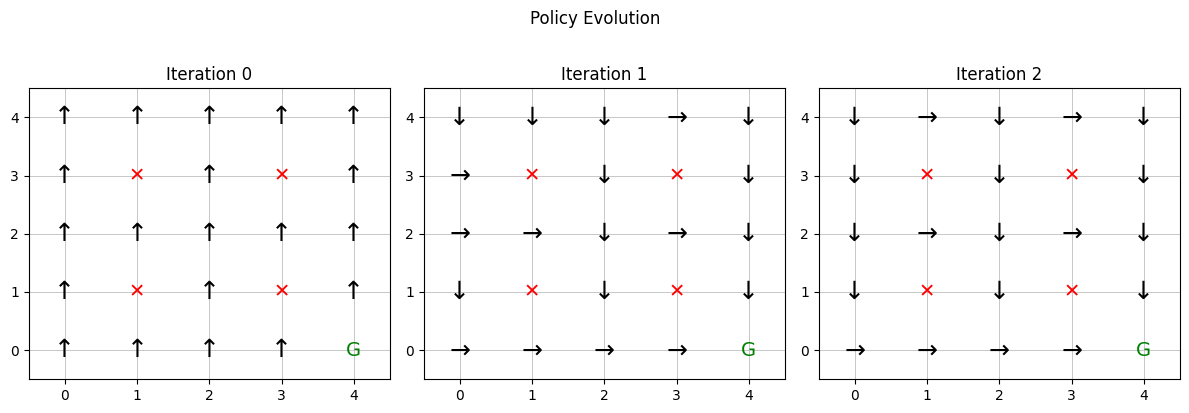

In [4]:
# Show policy evolution
n_iters = len(pol_hist)
fig, axes = plt.subplots(1, n_iters, figsize=(4*n_iters, 4))
if n_iters == 1: axes = [axes]
for ax, (pi, title) in enumerate(zip(pol_hist, [f'Iter {i}' for i in range(n_iters)])):
    axes[ax].set_xlim(-0.5, 4.5); axes[ax].set_ylim(-0.5, 4.5)
    axes[ax].set_xticks(range(5)); axes[ax].set_yticks(range(5))
    axes[ax].grid(True, linewidth=0.5)
    for s in range(25):
        r, c = divmod(s, 5)
        if (r,c) == env.goal:         axes[ax].text(c, 4-r, 'G', ha='center', va='center', fontsize=14, color='green')
        elif (r,c) in env.pits:       axes[ax].text(c, 4-r, '✕', ha='center', va='center', fontsize=14, color='red')
        else:                         axes[ax].text(c, 4-r, env.ACTION_SYMBOLS[pol_hist[ax][s]], ha='center', va='center', fontsize=18)
    axes[ax].set_title(f'Iteration {ax}')
plt.suptitle('Policy Evolution', y=1.02); plt.tight_layout(); plt.show()

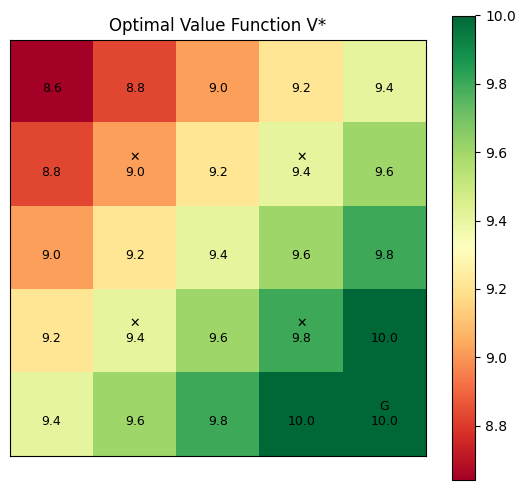

In [5]:
# Final optimal value function
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(opt_V.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=ax)
for s in range(25):
    r,c = divmod(s,5)
    label = 'G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    ax.text(c, r, f'{label}\n{opt_V[s]:.1f}', ha='center', va='center', fontsize=9)
ax.set_title('Optimal Value Function V*'); ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Add a 'treasure' cell at (2,2) giving +3 reward (non-terminal). Does the optimal policy change to seek it?
2. Change pits to non-terminal (-5 reward but keep going). How does the policy change?
3. **Challenge**: implement **modified policy iteration** — only do k=5 steps of evaluation per improvement instead of full convergence. Does it still find the optimal policy?

### Exercises 1 & 2: Environment Dynamics Analysis

**1. Treasure at (2,2) [Non-Terminal, +3 Reward]:**
Since the treasure is non-terminal, the agent doesn't just seek it once—it has the potential to farm it. If moving back and forth across the treasure yields a net positive return (even with step costs), the optimal policy will change to indefinitely loop over `(2,2)` instead of heading to the Goal, because an infinite sum of +3 rewards outscales a one-time +10 reward.

**2. Non-Terminal Pits [-5 Penalty]:**
The optimal policy still heavily avoids the pits because -5 is a massive penalty. However, the fundamental difference is that falling into a pit no longer acts as a "game over." The agent will chart a path *out* of the pit towards the goal rather than the state just being a black hole.

In [7]:
# ==========================================
# Exercises 1 & 2: Modified GridWorld
# ==========================================
class ModGridWorld(GridWorld):
    def transitions(self, s, a):
        r, c = divmod(s, self.size)
        dr, dc = self.ACTIONS[a]
        nr = max(0, min(self.size-1, r+dr))
        nc = max(0, min(self.size-1, c+dc))
        ns = nr * self.size + nc

        # Original Goal
        if (nr, nc) == self.goal:
            return [(1.0, ns, +10.0, True)]

        # Ex 2: Pits are now NON-TERMINAL (False), just a -5 penalty
        if (nr, nc) in self.pits:
            return [(1.0, ns, -5.0, False)]

        # Ex 1: Treasure at (2,2) with +3 reward, NON-TERMINAL
        if (nr, nc) == (2, 2):
            return [(1.0, ns, +3.0, False)]

        return [(1.0, ns, -0.1, False)]

print("--- Running Policy Iteration on Modified Env ---")
mod_env = ModGridWorld()
# You will see the agent gets stuck farming the treasure!
mod_policy, mod_V, _, _ = policy_iteration(mod_env)


# ==========================================
# Exercise 3: Challenge - Modified Policy Iteration
# ==========================================
def modified_policy_eval(env, policy, V, gamma=0.99, k_steps=5):
    """Truncated evaluation: Only does k sweeps instead of full convergence."""
    for _ in range(k_steps):
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            v = sum(policy[s,a] * sum(p*(r + (0 if d else gamma*V[ns]))
                    for p,ns,r,d in env.transitions(s,a))
                    for a in range(env.n_actions()))
            V_new[s] = v
        V = V_new
    return V

def modified_policy_iteration(env, gamma=0.99, k_steps=5):
    policy = np.ones((env.n_states(), env.n_actions())) / env.n_actions()
    V = np.zeros(env.n_states()) # Keep V across iterations
    iteration = 0

    while True:
        # 1. Truncated Evaluation (k steps)
        V = modified_policy_eval(env, policy, V, gamma, k_steps)

        # 2. Policy Improvement
        new_policy = policy_improvement(env, V, gamma)

        if np.array_equal(new_policy.argmax(1), policy.argmax(1)):
            print(f"Modified PI (k={k_steps}) converged in {iteration+1} iterations.")
            return policy, V

        policy = new_policy
        iteration += 1

print("\n--- Running Modified Policy Iteration (k=5) on Original Env ---")

mod_pi_policy, mod_pi_V = modified_policy_iteration(env)

if np.array_equal(mod_pi_policy.argmax(1), opt_policy.argmax(1)):
    print("Success! Modified Policy Iteration found the exact same optimal policy.")
else:
    print("Mismatch found.")

--- Running Policy Iteration on Modified Env ---
Policy iteration converged in 6 iterations

--- Running Modified Policy Iteration (k=5) on Original Env ---
Modified PI (k=5) converged in 5 iterations.
Success! Modified Policy Iteration found the exact same optimal policy.
